# Projeto 1 — Spread CDI – IPCA (2010–2024)
**Autor:** Lucas Abreu

Análise mensal do spread entre CDI e IPCA no mercado brasileiro, identificando os ciclos de maior e menor atratividade para o investidor em renda fixa.


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time

print('Bibliotecas carregadas!')
print(f'pandas: {pd.__version__}')

Bibliotecas carregadas!
pandas: 2.2.3


In [2]:
def get_bcb_series(codigo_serie, data_inicio, data_fim, nome):
    url = (
        f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados'
        f'?formato=json&dataInicial={data_inicio}&dataFinal={data_fim}'
    )
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    df = pd.DataFrame(response.json())
    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
    df['valor'] = pd.to_numeric(df['valor'].str.replace(',', '.'), errors='coerce')
    df = df.set_index('data').rename(columns={'valor': nome})
    return df


def get_bcb_series_completo(codigo_serie, nome):
    periodos = [
        ('01/01/2010', '31/12/2014'),
        ('01/01/2015', '31/12/2019'),
        ('01/01/2020', '31/12/2024'),
    ]
    partes = []
    for inicio, fim in periodos:
        df_parte = get_bcb_series(codigo_serie, inicio, fim, nome)
        partes.append(df_parte)
        time.sleep(2)
    resultado = pd.concat(partes)
    print(f'  v {nome}: {len(resultado)} registros')
    return resultado


print('Funcoes definidas!')

Funcoes definidas!


In [3]:
SERIES = {
    432:  'SELIC_meta',
    433:  'IPCA_mensal',
    12:   'SELIC_efetiva',
    4389: 'CDI_anual',
}

print('Coletando dados de 2010 a 2024 (pode demorar ~1 minuto)...')
frames = []
for codigo, nome in SERIES.items():
    print(f'\nColetando {nome}...')
    df_serie = get_bcb_series_completo(codigo, nome)
    frames.append(df_serie)

df = pd.concat(frames, axis=1)
df = df[~df.index.duplicated(keep='first')]
df = df.sort_index()

print(f'\nDataset final: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.tail(3)

Coletando dados de 2010 a 2024 (pode demorar ~1 minuto)...

Coletando SELIC_meta...
  v SELIC_meta: 5479 registros

Coletando IPCA_mensal...
  v IPCA_mensal: 180 registros

Coletando SELIC_efetiva...
  v SELIC_efetiva: 3767 registros

Coletando CDI_anual...
  v CDI_anual: 3767 registros

Dataset final: 5479 linhas x 4 colunas


,SELIC_meta,IPCA_mensal,SELIC_efetiva,CDI_anual
data,,,,
2024-12-29,12.25,NaN,NaN,NaN
2024-12-30,12.25,NaN,0.045513,12.15
2024-12-31,12.25,NaN,0.045513,12.15


In [4]:
# Resample para frequencia mensal
df_mensal = df.resample('ME').last().ffill()

# Converter CDI anual para mensal (capitalizacao composta)
df_mensal['CDI_mensal'] = ((1 + df_mensal['CDI_anual'] / 100) ** (1/12) - 1) * 100

# Spread CDI-IPCA: CDI mensal - IPCA mensal (mesma base percentual ao mes)
df_mensal['spread_cdi_ipca'] = df_mensal['CDI_mensal'] - df_mensal['IPCA_mensal']

print('Indicadores criados!')
print('\nBase de calculo: ambos em % ao mes')
df_mensal[['CDI_mensal', 'IPCA_mensal', 'spread_cdi_ipca']].tail(6).round(3)

Indicadores criados!

Base de calculo: ambos em % ao mes


,CDI_mensal,IPCA_mensal,spread_cdi_ipca
data,,,
2024-07-31,0.828,0.38,0.448
2024-08-31,0.828,-0.02,0.848
2024-09-30,0.847,0.44,0.407
2024-10-31,0.847,0.56,0.287
2024-11-30,0.885,0.39,0.495
2024-12-31,0.960,0.52,0.440


In [5]:
print('=== Qualidade dos dados ===')
print(f'Periodo: {df_mensal.index.min().date()} a {df_mensal.index.max().date()}')
print(f'\nValores nulos:')
print(df_mensal[['CDI_mensal', 'IPCA_mensal', 'spread_cdi_ipca']].isnull().sum())
print(f'\nEstatisticas descritivas (% ao mes):')
df_mensal[['CDI_mensal', 'IPCA_mensal', 'spread_cdi_ipca']].describe().round(3)

=== Qualidade dos dados ===
Periodo: 2010-01-31 a 2024-12-31

Valores nulos:
CDI_mensal         0
IPCA_mensal        0
spread_cdi_ipca    0
dtype: int64

Estatisticas descritivas (% ao mes):


,CDI_mensal,IPCA_mensal,spread_cdi_ipca
count,180.000,180.000,180.000
mean,0.755,0.477,0.278
std,0.269,0.360,0.442
min,0.157,-0.680,-1.193
25%,0.557,0.248,0.055
50%,0.828,0.450,0.312
75%,0.960,0.710,0.544
max,1.108,1.620,1.715


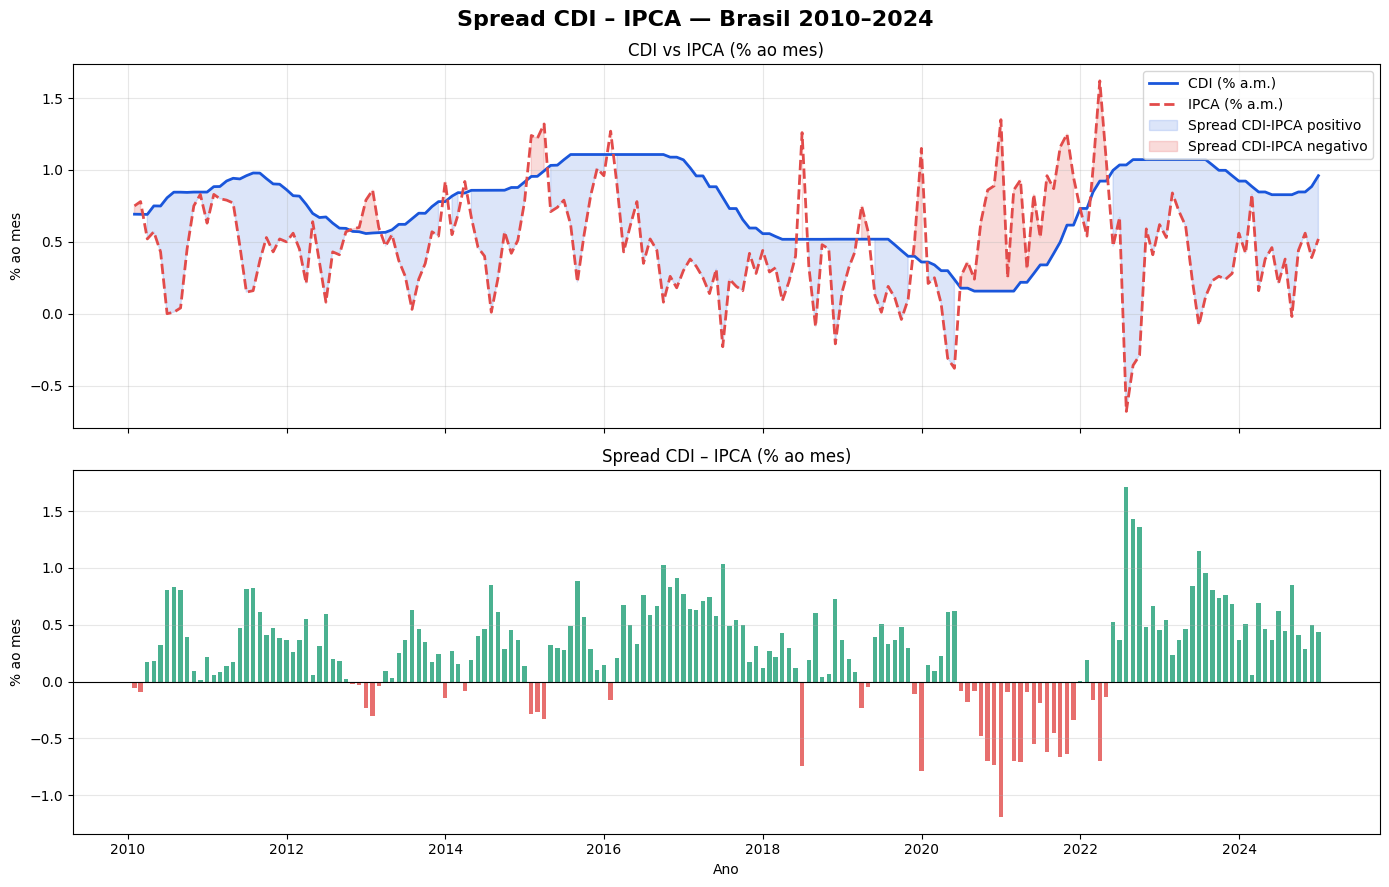

Grafico 1 salvo!


In [6]:
# ── GRAFICO 1: CDI vs IPCA com area de spread ─────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Spread CDI – IPCA — Brasil 2010–2024', fontsize=16, fontweight='bold')

ax1 = axes[0]
ax1.plot(df_mensal.index, df_mensal['CDI_mensal'], label='CDI (% a.m.)', color='#1A56DB', linewidth=2)
ax1.plot(df_mensal.index, df_mensal['IPCA_mensal'], label='IPCA (% a.m.)', color='#E24B4A', linewidth=2, linestyle='--')
ax1.fill_between(df_mensal.index, df_mensal['CDI_mensal'], df_mensal['IPCA_mensal'],
                 where=df_mensal['CDI_mensal'] >= df_mensal['IPCA_mensal'],
                 alpha=0.15, color='#1A56DB', label='Spread CDI-IPCA positivo')
ax1.fill_between(df_mensal.index, df_mensal['CDI_mensal'], df_mensal['IPCA_mensal'],
                 where=df_mensal['CDI_mensal'] < df_mensal['IPCA_mensal'],
                 alpha=0.2, color='#E24B4A', label='Spread CDI-IPCA negativo')
ax1.set_ylabel('% ao mes')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title('CDI vs IPCA (% ao mes)')

ax2 = axes[1]
cores = ['#1D9E75' if v >= 0 else '#E24B4A' for v in df_mensal['spread_cdi_ipca']]
ax2.bar(df_mensal.index, df_mensal['spread_cdi_ipca'], color=cores, alpha=0.8, width=20)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('% ao mes')
ax2.set_xlabel('Ano')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_title('Spread CDI – IPCA (% ao mes)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig('grafico1_spread_cdi_ipca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico 1 salvo!')

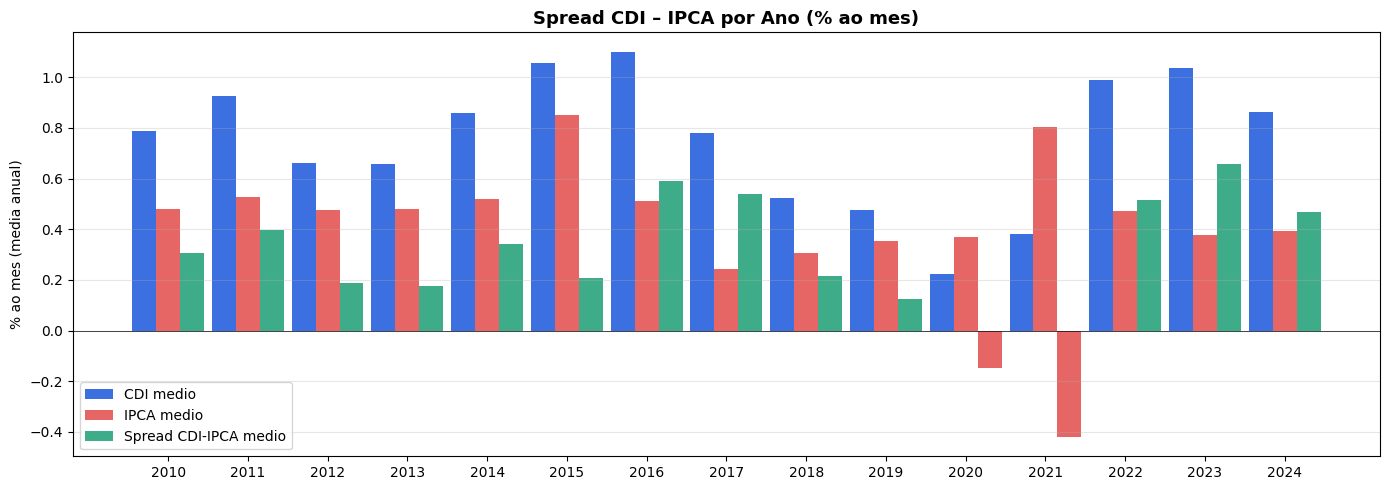

Grafico 2 salvo!


In [7]:
# ── GRAFICO 2: Medias anuais ───────────────────────────────
df_anual = df_mensal[['CDI_mensal', 'IPCA_mensal', 'spread_cdi_ipca']].groupby(df_mensal.index.year).mean().round(3)
df_anual.columns = ['CDI medio (a.m.)', 'IPCA medio (a.m.)', 'Spread CDI-IPCA medio (a.m.)']

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(df_anual))
width = 0.3
ax.bar([i - width for i in x], df_anual['CDI medio (a.m.)'], width, label='CDI medio', color='#1A56DB', alpha=0.85)
ax.bar([i for i in x], df_anual['IPCA medio (a.m.)'], width, label='IPCA medio', color='#E24B4A', alpha=0.85)
ax.bar([i + width for i in x], df_anual['Spread CDI-IPCA medio (a.m.)'], width, label='Spread CDI-IPCA medio',
       color=['#1D9E75' if v >= 0 else '#E24B4A' for v in df_anual['Spread CDI-IPCA medio (a.m.)']], alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(df_anual.index)
ax.set_ylabel('% ao mes (media anual)')
ax.set_title('Spread CDI – IPCA por Ano (% ao mes)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('grafico2_spread_anual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico 2 salvo!')

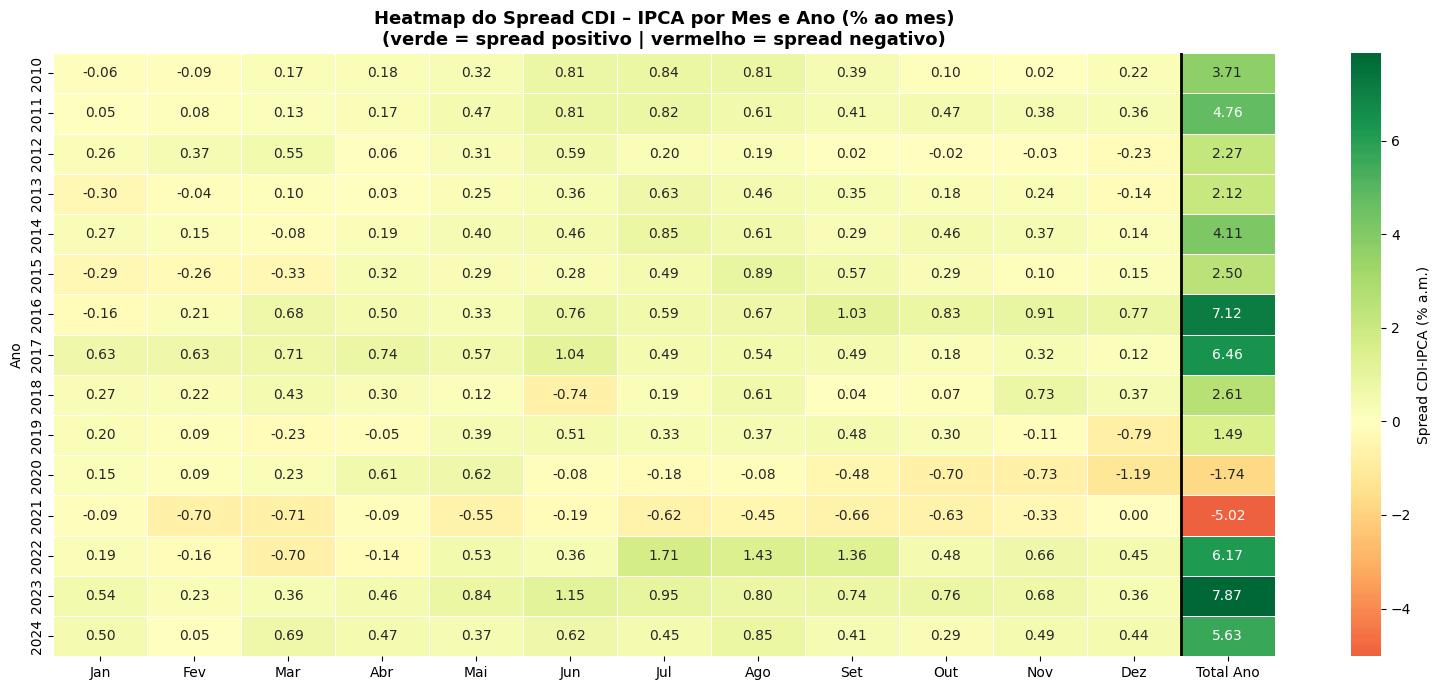

Grafico 3 salvo!


In [8]:
# ── GRAFICO 3: Heatmap com total anual ────────────────────
pivot_df = pd.DataFrame({
    'Ano': df_mensal.index.year,
    'Mes': df_mensal.index.month,
    'spread_cdi_ipca': df_mensal['spread_cdi_ipca'].values
})
heatmap_data = pivot_df.pivot(index='Ano', columns='Mes', values='spread_cdi_ipca').round(2)
heatmap_data.columns = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

# Coluna de total acumulado no ano
heatmap_data['Total Ano'] = heatmap_data.sum(axis=1).round(2)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    cbar_kws={'label': 'Spread CDI-IPCA (% a.m.)'},
    linecolor='white'
)
ax.axvline(x=12, color='black', linewidth=2)
ax.set_title('Heatmap do Spread CDI – IPCA por Mes e Ano (% ao mes)\n(verde = spread positivo | vermelho = spread negativo)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Ano')
plt.tight_layout()
plt.savefig('grafico3_heatmap_spread_cdi_ipca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico 3 salvo!')

In [9]:
# ── ANALISE: Melhores e piores periodos ───────────────────
top5_melhor = df_mensal[['CDI_mensal', 'IPCA_mensal', 'spread_cdi_ipca']].nlargest(5, 'spread_cdi_ipca')
top5_pior   = df_mensal[['CDI_mensal', 'IPCA_mensal', 'spread_cdi_ipca']].nsmallest(5, 'spread_cdi_ipca')

print('=== TOP 5 MELHORES MESES (maior spread CDI-IPCA) ===')
print(top5_melhor.round(3).to_string())
print('\n=== TOP 5 PIORES MESES (menor spread CDI-IPCA) ===')
print(top5_pior.round(3).to_string())

pct_positivo = (df_mensal['spread_cdi_ipca'] > 0).mean() * 100
spread_medio = df_mensal['spread_cdi_ipca'].mean()

print(f'\n=== RESUMO DO PERIODO ===')
print(f'  Spread CDI-IPCA medio:         {spread_medio:.3f}% a.m.')
print(f'  % do tempo com spread > 0:     {pct_positivo:.1f}%')
print(f'  CDI maximo (a.m.):             {df_mensal["CDI_mensal"].max():.3f}%')
print(f'  IPCA maximo (a.m.):            {df_mensal["IPCA_mensal"].max():.3f}%')

=== TOP 5 MELHORES MESES (maior spread CDI-IPCA) ===
            CDI_mensal  IPCA_mensal  spread_cdi_ipca
data                                                
2022-07-31       1.035        -0.68            1.715
2022-08-31       1.072        -0.36            1.432
2022-09-30       1.072        -0.29            1.362
2023-06-30       1.072        -0.08            1.152
2017-06-30       0.808        -0.23            1.038

=== TOP 5 PIORES MESES (menor spread CDI-IPCA) ===
            CDI_mensal  IPCA_mensal  spread_cdi_ipca
data                                                
2020-12-31       0.157         1.35           -1.193
2019-12-31       0.359         1.15           -0.791
2018-06-30       0.518         1.26           -0.742
2020-11-30       0.157         0.89           -0.733
2021-03-31       0.218         0.93           -0.712

=== RESUMO DO PERIODO ===
  Spread CDI-IPCA medio:         0.278% a.m.
  % do tempo com spread > 0:     78.3%
  CDI maximo (a.m.):             1.108%
  

## Conclusões
## Conclusões

Com base na análise realizada, seguem conclusões:

1. No período analisado (2010–2024), o spread CDI–IPCA se manteve positivo em 78,3% dos meses, com média de 0,278% ao mês, indicando que a renda fixa brasileira ofereceu proteção consistente contra a inflação na maior parte do tempo, mesmo em períodos de maior volatilidade, como o impeachment, a greve dos caminhoneiros e a pandemia.

2. Os períodos de maior atratividade para o investidor em renda fixa foram 2016 e 2022–2023, quando o spread CDI–IPCA atingiu os maiores valores acumulados anuais — 7,12% e 7,87% respectivamente. Os 5 melhores meses do período foram concentrados em 2022, com destaque para julho/2022, que registrou spread de 1,715% a.m., reflexo da combinação de CDI elevado com deflação naquele mês.

3. O período de maior compressão foi 2020–2021, com spread acumulado anual de -1,74% em 2020 e -5,02% em 2021 — os únicos anos com total negativo no período. O pior mês foi dezembro/2020, com spread de -1,193% a.m., quando o CDI estava na mínima histórica de 0,157% a.m. e o IPCA atingiu 1,35% a.m. Nesse cenário, investidores em produtos pós-fixados convencionais viram seu retorno real negativo, o que justificou a migração para ativos de maior risco como fundos multimercado e renda variável.

4. O heatmap revelou um padrão assimétrico em 2021: o spread saiu de -0,09% em janeiro e encerrou o ano em 0,00% em dezembro, refletindo o início do ciclo de alta da SELIC a partir de março daquele ano. Quem antecipou esse movimento e alocou em prefixados ou títulos IPCA+ no início de 2021 capturou taxas historicamente atrativas antes da virada do ciclo.

5. A análise evidencia que a estratégia de alocação em renda fixa no Brasil deve acompanhar os ciclos da política monetária. Em períodos de alta da SELIC, produtos pós-fixados atrelados ao CDI oferecem proteção e retorno real consistente. Nos momentos de pico do ciclo como em 2016 e 2023 a migração para prefixados ou títulos IPCA+ de duration mais longa permite capturar taxas elevadas por períodos prolongados. Em ciclos de queda como 2020, a diversificação para outras classes de ativos torna-se necessária para preservar o retorno real da carteira.

---
*Dados: Banco Central do Brasil (SGS) · Análise: Lucas Abreu*